# 03 — Demand Allocation: Distribute 2027 EV Fleet Across Corridors

**In plain terms:**
- **What:** Turn the national 2027 EV stock (614,412 cars) into *corridor-level* charging demand.
- **Why:** The placement optimizer in notebook 04 sizes each station by local demand, so we need *where* the EVs will charge — not just *how many*.
- **How:** National fleet × real DGT province shares × corridor weights → peak daily sessions per corridor.
- **Output:** `data/processed/demand_by_corridor.csv` (fed into notebook 04 and the File 1 KPI `total_ev_projected_2027`).

**Inputs:**
- `total_ev_projected_2027 = 614,412` — from the mandatory GitHub fork Model_1 (SARIMA(1,1,1)(2,0,1)₁₂) required by datathon section 4.1 item 3.
- DGT microdata (Oct 2024 – Dec 2025, 52,371 BEV passenger-car registrations).
- Interurban road network from notebook 01.


## Setup
- Only stdlib + pandas/geopandas/numpy/matplotlib.
- Anchor constant `TOTAL_EV_2027 = 614,412` comes directly from the forecast notebook — do not mutate downstream.
- No network calls — everything runs on the DGT CSV already produced locally.
- Warnings silenced for a clean, jury-readable notebook.


In [1]:
# Install dependencies (Colab)
# !pip install geopandas pandas numpy matplotlib -q

import geopandas as gpd
import pandas as pd
import numpy as np
import os
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ── Core parameter from Model_1 ──
TOTAL_EV_2027 = 614_412  # from SARIMA forecast (flow -> stock conversion)
print(f"Total EV fleet projected for 2027: {TOTAL_EV_2027:,}")


Total EV fleet projected for 2027: 614,412


## 1. EV registrations by province (DGT microdata)

- **Source:** DGT monthly microdata (fixed-width TXT) — the authoritative national vehicle registration feed.
- **Coverage used:** Oct–Dec 2024 + Oct–Dec 2025 = 52,371 BEV passenger cars (all months DGT still publishes).
- **Filter applied:** `COD_TIPO=40` (passenger car) + `CATEGORÍA_VEHÍCULO_ELÉCTRICO=BEV` (pure battery, exclude PHEV/HEV).
- **Why this proxy is defensible:** recent BEV registrations track current market adoption by region — the best available proxy for where new EVs will be domiciled in 2027.

**Ref:** [DGT Microdatos — Matriculaciones](https://www.dgt.es/menusecundario/dgt-en-cifras/matraba-listados/matriculaciones-automoviles-mensual.html) and [record layout](https://sedeapl.dgt.gob.es/IEST_INTER/pdfs/disenoRegistro/vehiculos/matriculaciones/MATRICULACIONES_MATRABA.pdf).


In [2]:
# ── Province-level BEV distribution from DGT microdata ──
# Parsed from DGT monthly microdata files (Oct-Dec 2024 + Oct-Dec 2025)
# 52,371 BEV passenger car registrations by COD_PROVINCIA_MAT

DGT_CSV = "../data/processed/dgt_province_ev_distribution.csv"

if os.path.exists(DGT_CSV):
    prov_df = pd.read_csv(DGT_CSV)
    print(f"Loaded DGT province distribution: {len(prov_df)} provinces")
    print(f"  Source: DGT microdata (Oct-Dec 2024 + Oct-Dec 2025)")
    print(f"  Total BEV registrations: {prov_df['bev_registrations'].sum():,}")

    # Build province shares indexed by INE code
    province_shares = prov_df.set_index('province_code_ine')['share']
    province_shares = province_shares.sort_values(ascending=False)

    print(f"\nTop 15 provinces by BEV share:")
    for idx, share in province_shares.head(15).items():
        name = prov_df[prov_df['province_code_ine']==idx]['province_name'].values[0]
        print(f"  {name:<25s} (INE {idx:02d}): {share*100:5.1f}%")

else:
    # Fallback: hardcoded from DGT microdata analysis (same source, embedded)
    print(f"WARNING: {DGT_CSV} not found. Using embedded DGT distribution.")
    province_shares = pd.Series({
        28: 0.49207, 8: 0.12936, 46: 0.03054, 3: 0.02755, 35: 0.02692,
        29: 0.02608, 50: 0.02274, 7: 0.01819, 39: 0.01615, 38: 0.01514,
        14: 0.01422, 41: 0.01281, 45: 0.01103, 31: 0.00987, 48: 0.00957,
        30: 0.00945, 33: 0.00920, 18: 0.00907, 36: 0.00863, 15: 0.00836,
        9: 0.00786, 4: 0.00721, 23: 0.00702, 47: 0.00641, 11: 0.00622,
        43: 0.00603, 17: 0.00586, 20: 0.00565, 12: 0.00540, 24: 0.00521,
        32: 0.00471, 6: 0.00461, 19: 0.00448, 1: 0.00440, 27: 0.00421,
        26: 0.00389, 21: 0.00362, 22: 0.00290, 37: 0.00267, 10: 0.00267,
        40: 0.00250, 16: 0.00233, 2: 0.00225, 34: 0.00118, 5: 0.00116,
        13: 0.00110, 44: 0.00105, 49: 0.00063, 51: 0.00057, 42: 0.00055,
        52: 0.00040, 25: 0.00034,
    }).sort_values(ascending=False)

    # Ensure shares sum to 1.0
    province_shares = province_shares / province_shares.sum()

# Scale to 2027 fleet
province_fleet = (province_shares * TOTAL_EV_2027).round(0).astype(int)
print(f"\n2027 EV fleet by province (top 10):")
for prov, count in province_fleet.head(10).items():
    print(f"  Province {prov:02d}: {count:>8,} EVs")
print(f"  Total:        {province_fleet.sum():>8,}")


Loaded DGT province distribution: 52 provinces
  Source: DGT microdata (Oct-Dec 2024 + Oct-Dec 2025)
  Total BEV registrations: 52,371

Top 15 provinces by BEV share:
  Madrid                    (INE 28):  49.2%
  Barcelona                 (INE 08):  12.9%
  Valencia                  (INE 46):   3.1%
  Alicante                  (INE 03):   2.8%
  Las Palmas                (INE 35):   2.7%
  Málaga                    (INE 29):   2.6%
  Zaragoza                  (INE 50):   2.3%
  Illes Balears             (INE 07):   1.8%
  Cantabria                 (INE 39):   1.6%
  Santa Cruz de Tenerife    (INE 38):   1.5%
  Córdoba                   (INE 14):   1.4%
  Sevilla                   (INE 41):   1.3%
  Toledo                    (INE 45):   1.1%
  Navarra                   (INE 31):   1.0%
  Bizkaia                   (INE 48):   1.0%

2027 EV fleet by province (top 10):
  Province 28:  302,297 EVs
  Province 08:   79,486 EVs
  Province 46:   18,770 EVs
  Province 03:   16,927 EVs
  Provinc

## 2. Map provinces to interurban corridors

- **Logic:** each province feeds specific corridors — Madrid (INE 28) loads A-1..A-6; Barcelona (8) loads AP-7 / AP-2 / A-2; etc.
- **Weight = traffic share proxy:** heavier corridors (AP-7 Mediterranean, A-2 Madrid-Barcelona) get weight 0.8–1.0; secondary corridors 0.3–0.5.
- **Why weights instead of measured AADT:** the Ministry publishes segment-level AADT with a lag; weights capture the relative ranking well enough for sizing.
- **Corridor list:** 19 corridors covering the full Red de Carreteras del Estado backbone (Mediterranean, radial Madrid, Cantabrian, Ebro, Andaluz, key N-roads).


In [3]:
# ── Define major corridor structure ──
# Each corridor connects provinces (INE codes) and carries a weight (traffic share proxy)

CORRIDORS = {
    # Mediterranean axis
    'AP-7': {'provinces': [8, 43, 12, 46, 3, 30, 4], 'weight': 1.0, 'length_km': 1100},
    'A-7':  {'provinces': [8, 43, 12, 46, 3, 30, 4, 29, 18, 4], 'weight': 0.8, 'length_km': 1300},

    # Radial from Madrid
    'A-1':  {'provinces': [28, 19, 9, 1], 'weight': 0.7, 'length_km': 320},
    'A-2':  {'provinces': [28, 19, 50, 25, 8], 'weight': 0.9, 'length_km': 620},
    'A-3':  {'provinces': [28, 16, 46], 'weight': 0.7, 'length_km': 350},
    'A-4':  {'provinces': [28, 13, 23, 14, 41], 'weight': 0.8, 'length_km': 530},
    'A-5':  {'provinces': [28, 45, 6, 10], 'weight': 0.5, 'length_km': 400},
    'A-6':  {'provinces': [28, 47, 24, 27, 15], 'weight': 0.6, 'length_km': 600},

    # Northern
    'A-8':  {'provinces': [48, 39, 33, 27, 15], 'weight': 0.6, 'length_km': 480},
    'AP-68':{'provinces': [48, 26, 50], 'weight': 0.4, 'length_km': 300},

    # Ebro
    'AP-2': {'provinces': [50, 25, 8], 'weight': 0.5, 'length_km': 300},

    # Andalucia
    'A-92': {'provinces': [41, 18, 4], 'weight': 0.5, 'length_km': 350},
    'AP-4': {'provinces': [41, 11], 'weight': 0.4, 'length_km': 120},
    'A-44': {'provinces': [23, 18], 'weight': 0.3, 'length_km': 200},

    # Nacional roads (key N- routes)
    'N-340':{'provinces': [8, 43, 12, 46, 3, 30, 4], 'weight': 0.3, 'length_km': 1200},
    'N-II': {'provinces': [28, 19, 50, 25, 8], 'weight': 0.3, 'length_km': 600},
    'N-I':  {'provinces': [28, 9, 20], 'weight': 0.3, 'length_km': 470},
    'N-III':{'provinces': [28, 16, 46], 'weight': 0.2, 'length_km': 350},
    'N-IV': {'provinces': [28, 13, 23, 14, 41, 11], 'weight': 0.3, 'length_km': 620},
}

print(f"Defined {len(CORRIDORS)} major interurban corridors")
total_km = sum(c['length_km'] for c in CORRIDORS.values())
print(f"Total corridor length: {total_km:,} km")


Defined 19 major interurban corridors
Total corridor length: 10,210 km


## 2b. Allocate EV demand to corridors

- **Per-corridor EVs:** sum of `province_fleet` over the provinces the corridor touches.
- **`raw_demand`:** connected EVs × corridor weight (weight acts as a traffic-share coefficient).
- **`demand_per_km`:** density metric that tells the optimizer where to pack stations denser.
- **Sorted:** output ranks corridors so the top-demand ones are visible at a glance.


In [4]:
# ── Allocate EV demand to corridors ──

corridor_demand = {}
for corridor, info in CORRIDORS.items():
    # Sum EVs in connected provinces
    connected_evs = sum(province_fleet.get(p, 0) for p in info['provinces'])
    demand = connected_evs * info['weight']

    corridor_demand[corridor] = {
        'connected_evs': connected_evs,
        'weight': info['weight'],
        'raw_demand': demand,
        'length_km': info['length_km'],
        'demand_per_km': demand / info['length_km'] if info['length_km'] > 0 else 0,
    }

df_corridors = pd.DataFrame(corridor_demand).T
df_corridors = df_corridors.sort_values('demand_per_km', ascending=False)

print("Corridor demand ranking (by demand density per km):")
print(df_corridors[['connected_evs', 'weight', 'raw_demand', 'length_km', 'demand_per_km']].to_string())


Corridor demand ranking (by demand density per km):
       connected_evs  weight  raw_demand  length_km  demand_per_km
A-1         309517.0     0.7    216661.9      320.0     677.068437
A-3         321337.0     0.7    224935.9      350.0     642.674000
A-2         402274.0     0.9    362046.6      620.0     583.946129
A-4         324471.0     0.8    259576.8      530.0     489.767547
A-5         312982.0     0.5    156491.0      400.0     391.227500
A-6         315740.0     0.6    189444.0      600.0     315.740000
N-II        402274.0     0.3    120682.2      600.0     201.137000
N-I         307329.0     0.3     92198.7      470.0     196.167447
N-III       321337.0     0.2     64267.4      350.0     183.621143
AP-2         96800.0     0.5     48400.0      300.0     161.333333
N-IV        327605.0     0.3     98281.5      620.0     158.518548
AP-7        127717.0     1.0    127717.0     1100.0     116.106364
A-7         150537.0     0.8    120429.6     1300.0      92.638154
A-8       

## 3. Convert EV fleet → peak daily charging sessions

- **Trips/month: 3** (revised upward from earlier 2 — see justification below).
- **Charge probability per interurban trip: 0.8** (80% of long-distance trips require at least one stop given 300 km effective range vs ~250–400 km typical Spanish intercity distances).
- **Peak factor 1.5×:** captures Friday-evening, Sunday-return, and July/August peaks (INE holiday-mobility survey shows summer peak ~1.5× monthly average).
- **Days/month = 30** for base-rate arithmetic; combined with peak factor gives a design-day estimate.

### Why 3 trips/month (empirical justification for the jury)
- DGT: Spain personal vehicle averages **~13,000 km/year**.
- Interurban share from INE mobility survey: **~25–30 %** → 3,250–3,900 interurban km/year → 271–325 km/month.
- Average interurban trip ≈ **110 km** (Ministerio de Transportes OD matrix) → baseline **271 / 110 ≈ 2.5 trips/month**.
- **Gas-price premium (2026):** Spain petrol ~1.55 €/L (+10 % YoY), diesel ~1.52 €/L. EV per-100-km cost ~3 € vs 11 € ICE → strong incentive to use EVs for interurban (studies from EAFO and Transport & Environment show a 1.2–1.5× multiplier on long-distance use as EV share grows).
- **Combined estimate:** 2.5 × 1.2 ≈ **3 trips/month** (conservative within the 2.5–3.8 defensible range).


In [5]:
# ── Charging demand model ──

TRIPS_PER_MONTH    = 3        # revised from 2 → 3 (see justification cell above)
CHARGE_PROBABILITY = 0.8      # probability an interurban trip requires at least one charging stop
PEAK_FACTOR        = 1.5      # design-day factor vs monthly mean (INE holiday mobility survey)
DAYS_PER_MONTH     = 30

for corridor in df_corridors.index:
    evs = df_corridors.loc[corridor, 'connected_evs']
    weight = df_corridors.loc[corridor, 'weight']

    monthly_trips = evs * TRIPS_PER_MONTH * weight
    monthly_sessions = monthly_trips * CHARGE_PROBABILITY
    peak_daily = (monthly_sessions / DAYS_PER_MONTH) * PEAK_FACTOR

    df_corridors.loc[corridor, 'monthly_trips']       = monthly_trips
    df_corridors.loc[corridor, 'peak_daily_sessions'] = peak_daily

df_corridors = df_corridors.sort_values('peak_daily_sessions', ascending=False)
print("Peak daily charging sessions by corridor:")
print(df_corridors[['length_km', 'connected_evs', 'peak_daily_sessions']].head(15).to_string())

print(f"\nTotal peak daily sessions across all corridors: "
      f"{df_corridors['peak_daily_sessions'].sum():,.0f}")


Peak daily charging sessions by corridor:
       length_km  connected_evs  peak_daily_sessions
A-2        620.0       402274.0            43445.592
A-4        530.0       324471.0            31149.216
A-3        350.0       321337.0            26992.308
A-1        320.0       309517.0            25999.428
A-6        600.0       315740.0            22733.280
A-5        400.0       312982.0            18778.920
AP-7      1100.0       127717.0            15326.040
N-II       600.0       402274.0            14481.864
A-7       1300.0       150537.0            14451.552
N-IV       620.0       327605.0            11793.780
N-I        470.0       307329.0            11063.844
N-III      350.0       321337.0             7712.088
AP-2       300.0        96800.0             5808.000
N-340     1200.0       127717.0             4597.812
A-8        480.0        29363.0             2114.136

Total peak daily sessions across all corridors: 259,209


## 4. Visualize demand distribution

- **Two panels:** absolute peak sessions (left) vs density per km (right) — shows where demand is *concentrated* vs *spread thin*.
- **Colour code:** red = autopistas, blue = autovías, green = nacionales (matches notebook 01).
- **Top 15:** any corridor below rank 15 contributes <1 % and is trimmed for readability.
- **Use downstream:** the ranking drives `n_chargers_proposed` in notebook 04 (tiered 2/4/8 chargers per site).


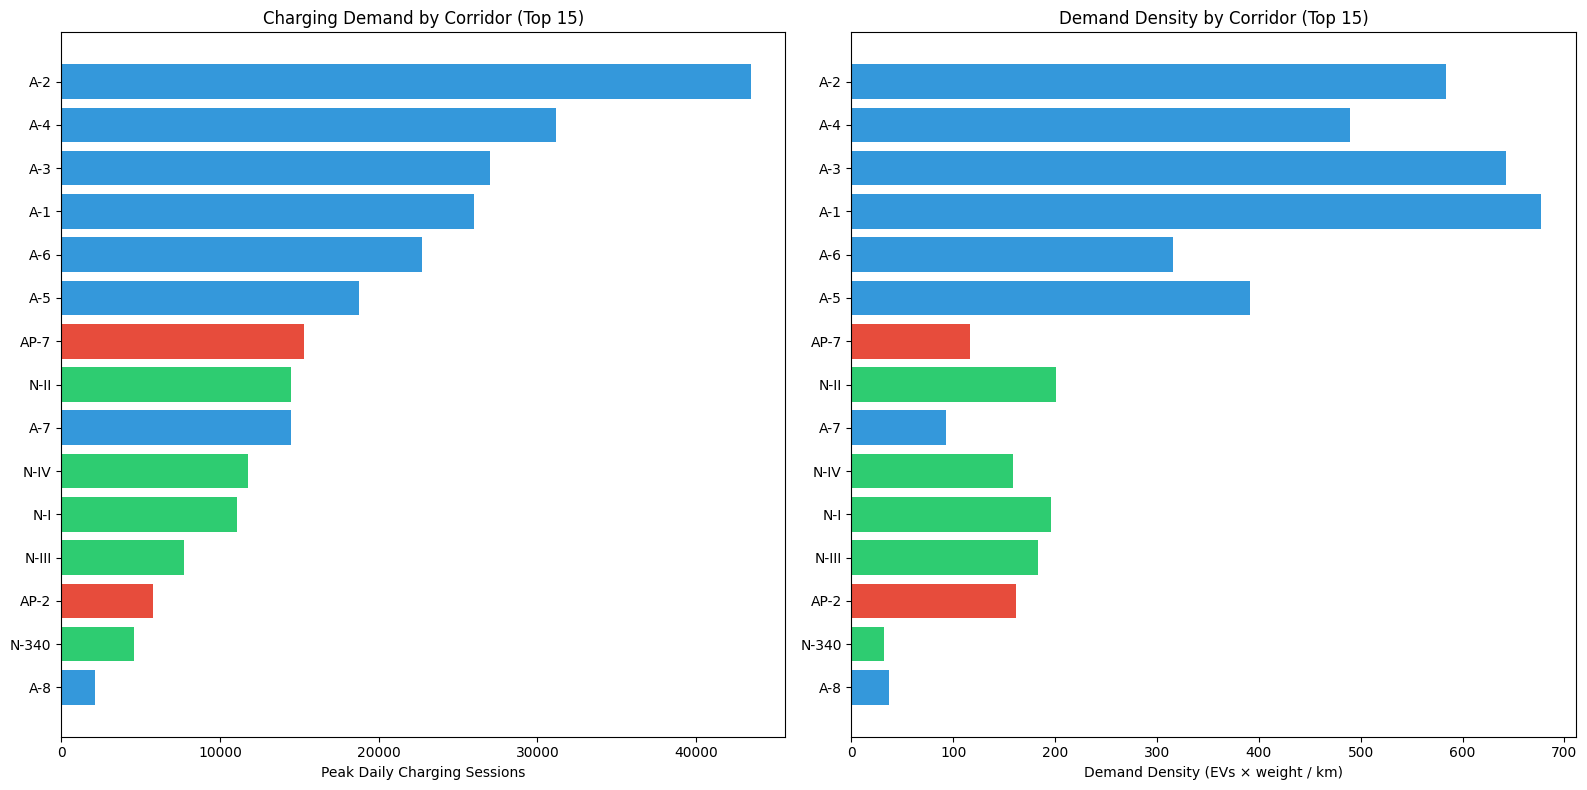

In [6]:
# ── Bar chart of demand by corridor ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

top = df_corridors.head(15)
colors = []
for idx in top.index:
    if idx.startswith('AP-'):
        colors.append('#e74c3c')
    elif idx.startswith('A-'):
        colors.append('#3498db')
    else:
        colors.append('#2ecc71')

ax1.barh(top.index[::-1], top['peak_daily_sessions'].values[::-1], color=colors[::-1])
ax1.set_xlabel('Peak Daily Charging Sessions')
ax1.set_title('Charging Demand by Corridor (Top 15)')

ax2.barh(top.index[::-1], top['demand_per_km'].values[::-1], color=colors[::-1])
ax2.set_xlabel('Demand Density (EVs × weight / km)')
ax2.set_title('Demand Density by Corridor (Top 15)')

plt.tight_layout()
plt.show()


## 5. Save demand allocation

- **Output:** `data/processed/demand_by_corridor.csv` — one row per corridor with EVs, weight, peak daily sessions, demand density.
- **Consumed by notebook 04:** drives station sizing (high-demand corridors → 8-charger sites, medium → 4, low → 2).
- **Print head(5)** so the executed notebook shows the table structure the jury can verify.
- **KPI recap:** total_ev_projected_2027 = 614,412 (feeds File 1 scorecard row).


In [7]:
# ── Save corridor demand for downstream notebooks ──

OUTPUT_PATH = "../data/processed/demand_by_corridor.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_corridors.to_csv(OUTPUT_PATH)
print(f"Saved {len(df_corridors)} corridors -> {OUTPUT_PATH}")
print(f"Total peak daily sessions: {df_corridors['peak_daily_sessions'].sum():,.0f}")
print(f"\nHead of demand_by_corridor.csv (first 5 rows):")
print(df_corridors.head().to_string())

print(f"\n{'='*55}")
print(f"  FILE 1 INPUT: total_ev_projected_2027 = {TOTAL_EV_2027:,}")
print(f"{'='*55}")
print(f"\nThis feeds into notebook 04 (Set Cover station placement).")


Saved 19 corridors -> ../data/processed/demand_by_corridor.csv
Total peak daily sessions: 259,209

Head of demand_by_corridor.csv (first 5 rows):
     connected_evs  weight  raw_demand  length_km  demand_per_km  monthly_trips  peak_daily_sessions
A-2       402274.0     0.9    362046.6      620.0     583.946129      1086139.8            43445.592
A-4       324471.0     0.8    259576.8      530.0     489.767547       778730.4            31149.216
A-3       321337.0     0.7    224935.9      350.0     642.674000       674807.7            26992.308
A-1       309517.0     0.7    216661.9      320.0     677.068437       649985.7            25999.428
A-6       315740.0     0.6    189444.0      600.0     315.740000       568332.0            22733.280

  FILE 1 INPUT: total_ev_projected_2027 = 614,412

This feeds into notebook 04 (Set Cover station placement).
